In [1]:
!pip install wfdb
# Had to install wfdb to read from PhysioNet datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 38.9 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.


In [2]:
from __future__ import annotations
import os
import pickle
from dataclasses import dataclass, field
from pathlib import Path
from typing import Optional

import numpy as np
import wfdb
from scipy import signal as sp_signal
from scipy.ndimage import gaussian_filter1d


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# MODULE 1 — CONFIG
# ─────────────────────────────────────────────────────────────────────────────

@dataclass
class Config:


    # ── Signal ──────────────────────────────────────────────────────────────
    TARGET_FS: int      = 100        # Unified sampling rate (Hz)
    WINDOW_S:  float    = 5.0        # Window length (seconds)
    STRIDE_S:  float    = 0.5        # Stride (seconds)

    # ── Filters ─────────────────────────────────────────────────────────────
    PPG_LOW:   float    = 0.1        # PPG bandpass low  (Hz) — isolates resp wave
    PPG_HIGH:  float    = 0.5        # PPG bandpass high (Hz)
    ECG_LOW:   float    = 1.0        # ECG bandpass low  (Hz)
    ECG_HIGH:  float    = 45.0       # ECG bandpass high (Hz)
    FILTER_ORDER: int   = 5          # Butterworth filter order

    # ── R-peak smoothing ─────────────────────────────────────────────────────
    RPEAK_SIGMA_S: float = 0.08      # Gaussian kernel σ for R-peak markers (s)

    # ── Ground truth labeling ────────────────────────────────────────────────
    MIN_BREATH_PERIOD_S: float = 1.5 # Shortest plausible breath (40 breaths/min)
    # Used to filter spurious extrema in the reference respiratory signal

    # ── Model ────────────────────────────────────────────────────────────────
    NUM_TRANSITIONS: int = 2         # tr1=inspiration onset, tr2=expiration onset
    ENCODER_CH: list     = field(default_factory=lambda: [32, 64])
    CORE_CH:    list     = field(default_factory=lambda: [64, 128, 128])
    DENSE_UNITS: int     = 128
    DROPOUT:    float    = 0.3

    # ── Loss ─────────────────────────────────────────────────────────────────
    ALPHA:      float    = 0.90      # Weight for classification loss
    #   Lower than PCG (0.99) because respiratory timing precision is the goal
    POS_WEIGHT: float    = 2.0       # BCE positive weight — missed breath = costly

    # ── Training ─────────────────────────────────────────────────────────────
    BATCH_SIZE: int      = 256
    GRAD_ACCUM: int      = 8         # Effective batch = 256 × 8 = 2048
    LR:         float    = 5e-4
    EPOCHS:     int      = 60
    PATIENCE:   int      = 6
    WEIGHT_DECAY: float  = 1e-4

    # ── Stitching ────────────────────────────────────────────────────────────
    VOTE_THRESHOLD: int  = 3
    PROB_THRESHOLD: float= 0.5
    REFRACTORY_S:  float = 1.5       # Min time between same-type transitions (s)

    # ── Paths (set these before running) ─────────────────────────────────────
    BIDMC_DIR: str = "/content/drive/MyDrive/Colab Notebooks/Data/bidmc-ppg-and-respiration-dataset-1.0.0"
    WESAD_DIR: str = "/content/drive/MyDrive/Colab Notebooks/Data/WESAD"
    CKPT_PATH: str = "/content/drive/MyDrive/Colab Notebooks/working/best_model.pt"

    # ── Derived (read-only) ──────────────────────────────────────────────────
    @property
    def WINDOW_SAMPLES(self) -> int:
        return int(self.TARGET_FS * self.WINDOW_S)

    @property
    def STRIDE_SAMPLES(self) -> int:
        return int(self.TARGET_FS * self.STRIDE_S)

    @property
    def REFRACTORY_SAMPLES(self) -> int:
        return int(self.TARGET_FS * self.REFRACTORY_S)

    @property
    def RPEAK_SIGMA_SAMPLES(self) -> float:
        return self.RPEAK_SIGMA_S * self.TARGET_FS



In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# MODULE 2 — PREPROCESSING UTILITIES
# ─────────────────────────────────────────────────────────────────────────────

class SignalProcessor:
    """Stateless signal processing helpers."""

    def __init__(self, cfg: Config):
        self.cfg = cfg

    # ── Resampling ──────────────────────────────────────────────────────────

    def resample(self, x: np.ndarray, orig_fs: float) -> np.ndarray:
        """Resample x from orig_fs to cfg.TARGET_FS using polyphase filtering."""
        if orig_fs == self.cfg.TARGET_FS:
            return x.astype(np.float32)
        num = len(x)
        target_len = int(np.round(num * self.cfg.TARGET_FS / orig_fs))
        return sp_signal.resample_poly(
            x,
            up=self.cfg.TARGET_FS,
            down=int(orig_fs),
        ).astype(np.float32)[:target_len]

    # ── Filtering ───────────────────────────────────────────────────────────

    def bandpass(self, x: np.ndarray, low: float, high: float) -> np.ndarray:
        """
        Zero-phase Butterworth bandpass at cfg.TARGET_FS.
        Uses sosfiltfilt for numerical stability.
        """
        nyq = self.cfg.TARGET_FS / 2.0
        sos = sp_signal.butter(
            self.cfg.FILTER_ORDER,
            # [low / nyq, high / nyq],
            [low,high],
            btype="band",
            output="sos",
            # opting to use internal value for butterworth normalising
            fs = self.cfg.TARGET_FS,
        )
        return sp_signal.sosfiltfilt(sos, x).astype(np.float32)

    # ── Normalisation ────────────────────────────────────────────────────────

    def normalize_window(self, x: np.ndarray) -> np.ndarray:
        """
        Robust per-window normalisation using 98th percentile of |x|.
        Prevents outlier peaks from dominating the scale.
        """
        denom = np.percentile(np.abs(x), 98)
        if denom < 1e-8:
            return x
        return (x / denom).astype(np.float32)

    # ── R-peak detection & smoothing ─────────────────────────────────────────

    def detect_rpeaks(self, ecg: np.ndarray) -> np.ndarray:
        """
        Simple gradient-based R-peak detector (no external library required).
        Returns a Gaussian-smoothed continuous indicator (same length as ecg).

        For higher accuracy on noisy wearable ECG, swap in NeuroKit2:
            import neurokit2 as nk
            _, info = nk.ecg_peaks(ecg, sampling_rate=cfg.TARGET_FS)
            peaks = info["ECG_R_Peaks"]
        """
        fs = self.cfg.TARGET_FS
        # 1. Smooth to suppress high-freq noise
        smoothed = sp_signal.savgol_filter(ecg, window_length=9, polyorder=3)
        # 2. Find all local maxima
        min_dist = int(0.3 * fs)                   # 200 bpm max
        peaks, _ = sp_signal.find_peaks(
            smoothed,
            distance=min_dist,
            height=np.percentile(smoothed, 60),    # only prominent peaks
        )
        # 3. Encode as binary spike train, then Gaussian-smooth
        indicator = np.zeros(len(ecg), dtype=np.float32)
        indicator[peaks] = 1.0
        sigma = self.cfg.RPEAK_SIGMA_SAMPLES
        return gaussian_filter1d(indicator, sigma=sigma).astype(np.float32)

    # ── Ground truth label extraction ────────────────────────────────────────

    def extract_transitions(self, resp: np.ndarray) -> np.ndarray:
        """
        Convert a continuous respiratory reference signal into an integer label
        array at TARGET_FS.

        Label encoding:
            0 = background (no transition)
            1 = inspiration onset  (tr1, local minimum of resp)
            2 = expiration  onset  (tr2, local maximum of resp)

        The resp signal is assumed to be ALREADY at TARGET_FS.
        """
        fs  = self.cfg.TARGET_FS
        min_dist = int(self.cfg.MIN_BREATH_PERIOD_S * fs / 2)

        # Smooth lightly before peak-finding to suppress artefacts
        resp_smooth = sp_signal.savgol_filter(
            resp, window_length=int(0.5 * fs) | 1, polyorder=2
        )

        # Local minima  → inspiration onsets (tr1)
        # find-peaks will find troughs when you feed flipped input signal
        troughs, _ = sp_signal.find_peaks(-resp_smooth, distance=min_dist,
                                           prominence=np.std(resp_smooth) * 0.3)
        # Local maxima  → expiration onsets  (tr2)
        peaks,   _ = sp_signal.find_peaks( resp_smooth, distance=min_dist,
                                           prominence=np.std(resp_smooth) * 0.3)

        labels = np.zeros(len(resp), dtype=np.int8)
        labels[troughs] = 1
        labels[peaks]   = 2
        return labels


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# BIDMC LOADER
# ─────────────────────────────────────────────────────────────────────────────

class BIDMCLoader:
    """
    Load all 53 BIDMC subjects and return a list of recording dicts.

    BIDMC file layout (after wfdb download):
        bidmc_01.hea / bidmc_01.dat      — signal data
        bidmc_01_Signals.csv             — optional (we use wfdb)

    wfdb channel order (0-indexed):
        0: PLETH  (PPG, 125 Hz)
        1: II     (ECG lead II, 125 Hz)
        2: RESP   (impedance respiratory, 125 Hz)

    Returns a list of dicts, each with keys:
        primary    : np.float32 (T,)   — filtered PPG
        auxiliary  : np.float32 (T,)   — filtered ECG
        aux_marker1: np.float32 (T,)   — Gaussian R-peak indicator
        labels     : np.int8    (T,)   — 0/1/2 transition labels
    """

    ORIG_FS  = 125

    def __init__(self, cfg: Config, root: Optional[str] = None):
        self.cfg  = cfg
        self.root = root or cfg.BIDMC_DIR
        self.proc = SignalProcessor(cfg)

    def load_all(self) -> list[dict]:
        root = Path(self.root)
        # BIDMC files are named bidmc01 … bidmc53
        record_names = sorted(root.glob("bidmc??.hea"))
        recordings   = []
        for hea in record_names:
            # SAFEST WAY: Strips the '.hea' extension from the absolute path
            record_base_path = str(hea.with_suffix(''))

            try:
                # Pass the clean path directly to _load_one
                rec = self._load_one(record_base_path)
                if rec is not None:
                    recordings.append(rec)
            except Exception as e:
                print(f"  [skip] {hea.name}: {e}")
        print(f"BIDMC: loaded {len(recordings)} / {len(record_names)} recordings.")
        return recordings

    def _load_one(self, record_path: str) -> Optional[dict]:
        record = wfdb.rdrecord(record_path)
        sig    = record.p_signal                        # (T, n_channels)
        channel_names = record.sig_name
        clean_channels = [name.replace(',', '').strip() for name in channel_names]
        idx_resp = clean_channels.index("RESP")
        idx_ppg = clean_channels.index("PLETH")
        idx_ecg = clean_channels.index("II")

        raw_ppg = sig[:,idx_ppg].astype(np.float32)
        raw_resp = sig[:,idx_resp].astype(np.float32)
        raw_ecg = sig[:,idx_ecg].astype(np.float32)
        # Drop recordings with excessive NaNs
        if np.isnan(raw_ppg).mean() > 0.05:
            return None

        # Fill isolated NaNs by linear interpolation
        raw_ppg  = _fill_nans(raw_ppg)
        raw_ecg  = _fill_nans(raw_ecg)
        raw_resp = _fill_nans(raw_resp)

        # Resample to TARGET_FS
        ppg  = self.proc.resample(raw_ppg,  self.ORIG_FS)
        ecg  = self.proc.resample(raw_ecg,  self.ORIG_FS)
        resp = self.proc.resample(raw_resp, self.ORIG_FS)

        # Filter
        ppg_f = self.proc.bandpass(ppg, self.cfg.PPG_LOW, self.cfg.PPG_HIGH)
        ecg_f = self.proc.bandpass(ecg, self.cfg.ECG_LOW, self.cfg.ECG_HIGH)

        # R-peak indicator (computed on filtered ECG)
        rpeak_marker = self.proc.detect_rpeaks(ecg_f)

        # Labels from reference respiratory signal
        labels = self.proc.extract_transitions(resp)

        return {
            "primary":     ppg_f,
            "auxiliary":   ecg_f,
            "aux_marker1": rpeak_marker,
            "labels":      labels,
            "subject_id":  Path(record_path).name,
        }



In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# WESAD LOADER
# ─────────────────────────────────────────────────────────────────────────────

class WESADLoader:
    """
    Load WESAD subjects for zero-shot validation.

    WESAD file layout:
        WESAD/S2/S2.pkl   — nested dict with keys 'signal', 'label', etc.

    Signals used:
        Wrist BVP (PPG) : 64 Hz    → key: data['signal']['wrist']['BVP']
        Chest ECG       : 700 Hz   → key: data['signal']['chest']['ECG']
        Chest RESP      : 700 Hz   → key: data['signal']['chest']['Resp']
          (chest belt = ground truth)

    Note: WESAD subject IDs 1 and 6 are missing; IDs go 2–17 (skipping 1,6,12).
    """

    FS_WRIST_PPG = 64
    FS_CHEST     = 700

    def __init__(self, cfg: Config, root: Optional[str] = None):
        self.cfg  = cfg
        self.root = root or cfg.WESAD_DIR
        self.proc = SignalProcessor(cfg)

    def load_all(self) -> list[dict]:
        root     = Path(self.root)
        subjects = sorted(root.glob("S*/S*.pkl"))
        recordings = []
        for pkl_path in subjects:
            try:
                rec = self._load_one(pkl_path)
                if rec is not None:
                    recordings.append(rec)
            except Exception as e:
                print(f"  [skip] {pkl_path.name}: {e}")
        print(f"WESAD: loaded {len(recordings)} / {len(subjects)} subjects.")
        return recordings

    def _load_one(self, pkl_path: Path) -> Optional[dict]:
        with open(pkl_path, "rb") as f:
            data = pickle.load(f, encoding="latin1")

        raw_ppg  = data["signal"]["wrist"]["BVP"].squeeze().astype(np.float32)
        raw_ecg  = data["signal"]["chest"]["ECG"].squeeze().astype(np.float32)
        raw_resp = data["signal"]["chest"]["Resp"].squeeze().astype(np.float32)

        ppg  = self.proc.resample(raw_ppg,  self.FS_WRIST_PPG)
        ecg  = self.proc.resample(raw_ecg,  self.FS_CHEST)
        resp = self.proc.resample(raw_resp, self.FS_CHEST)

        # Trim to shortest length after resampling
        T    = min(len(ppg), len(ecg), len(resp))
        ppg, ecg, resp = ppg[:T], ecg[:T], resp[:T]

        ppg_f = self.proc.bandpass(ppg, self.cfg.PPG_LOW, self.cfg.PPG_HIGH)
        ecg_f = self.proc.bandpass(ecg, self.cfg.ECG_LOW, self.cfg.ECG_HIGH)
        rpeak_marker = self.proc.detect_rpeaks(ecg_f)
        labels = self.proc.extract_transitions(resp)

        return {
            "primary":     ppg_f,
            "auxiliary":   ecg_f,
            "aux_marker1": rpeak_marker,
            "labels":      labels,
            "subject_id":  Path(pkl_path).parent.name,
        }


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────────────────────────────────────

def _fill_nans(x: np.ndarray) -> np.ndarray:
    """Linear interpolation over NaN runs."""
    nans = np.isnan(x)
    if not nans.any():
        return x
    idx = np.arange(len(x))
    x[nans] = np.interp(idx[nans], idx[~nans], x[~nans])
    return x


def subject_split(recordings: list, val_fraction: float = 0.15,
                  seed: int = 42) -> tuple[list, list]:
    """
    Split a list of recordings into train / val at the subject level.
    Ensures no subject leaks between splits.
    """
    rng  = np.random.default_rng(seed)
    idx  = np.arange(len(recordings))
    rng.shuffle(idx)
    n_val = max(1, int(len(idx) * val_fraction))
    val_idx   = idx[:n_val]
    train_idx = idx[n_val:]
    train = [recordings[i] for i in train_idx]
    val   = [recordings[i] for i in val_idx]
    return train, val


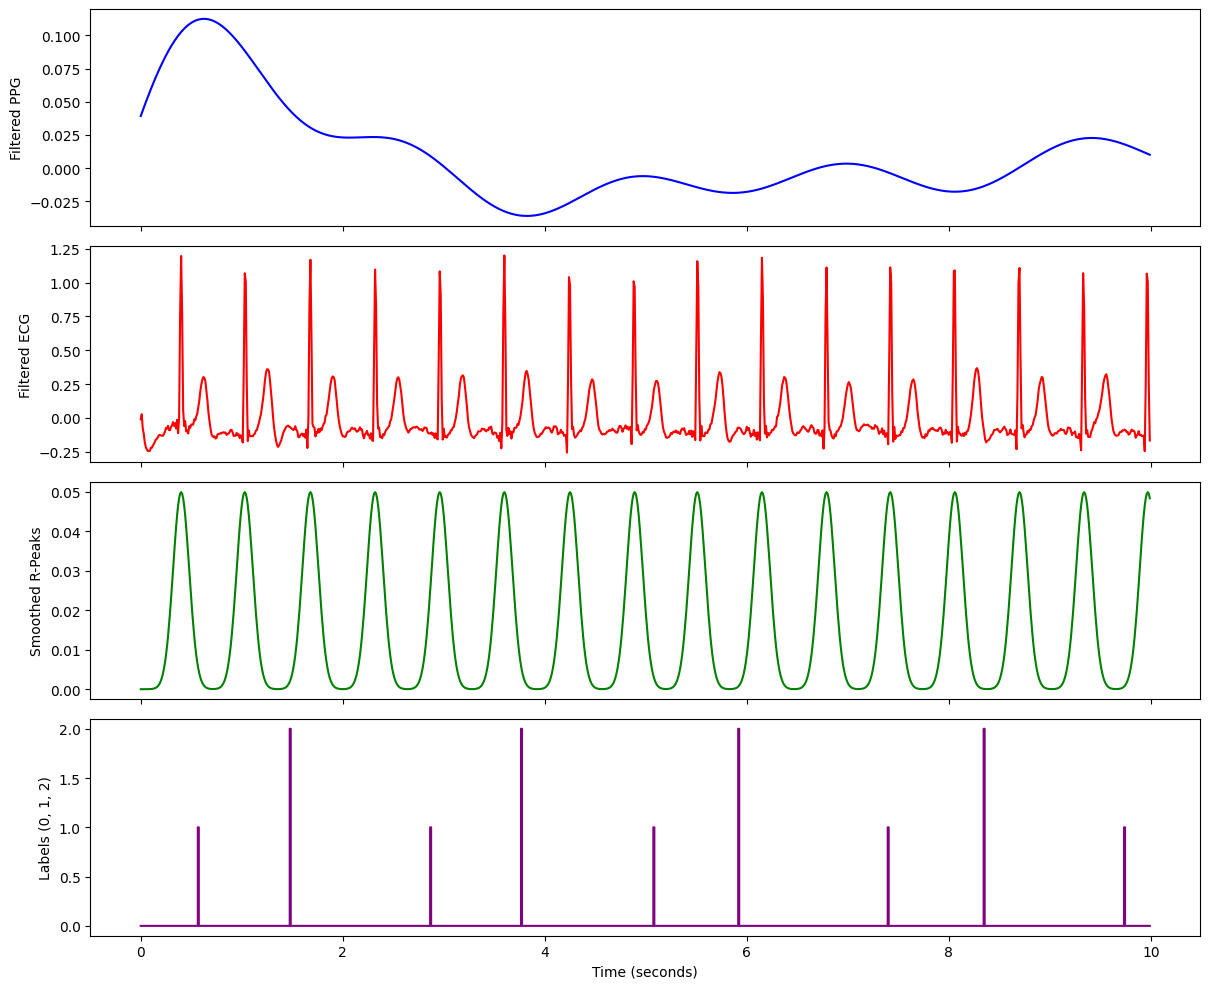

In [13]:
import matplotlib.pyplot as plt
import numpy as np

cfg = Config()
cfg.BIDMC_DIR = "/content/drive/MyDrive/Colab_Notebooks/Data/bidmc-ppg-and-respiration-dataset-1.0.0"
train_loader = BIDMCLoader(cfg)

sample = train_loader._load_one(f"{cfg.BIDMC_DIR}/bidmc01")

if sample is not None:
    T_plot = 1000
    time = np.arange(T_plot) / cfg.TARGET_FS

    ppg = sample["primary"][:T_plot]
    ecg = sample["auxiliary"][:T_plot]
    rpeaks = sample["aux_marker1"][:T_plot]
    labels = sample["labels"][:T_plot]

    # 4. Create stacked plots
    fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

    axes[0].plot(time, ppg, color='blue')
    axes[0].set_ylabel("Filtered PPG")

    axes[1].plot(time, ecg, color='red')
    axes[1].set_ylabel("Filtered ECG")

    axes[2].plot(time, rpeaks, color='green')
    axes[2].set_ylabel("Smoothed R-Peaks")

    axes[3].plot(time, labels, color='purple', drawstyle='steps-mid')
    axes[3].set_ylabel("Labels (0, 1, 2)")
    axes[3].set_xlabel("Time (seconds)")

    plt.tight_layout()
    plt.show()

else:
    print("File failed quality control or path was incorrect.")


In [14]:
# just to check if the preprocessing works for all the BIDMC datas
train_samples = train_loader.load_all()

BIDMC: loaded 53 / 53 recordings.


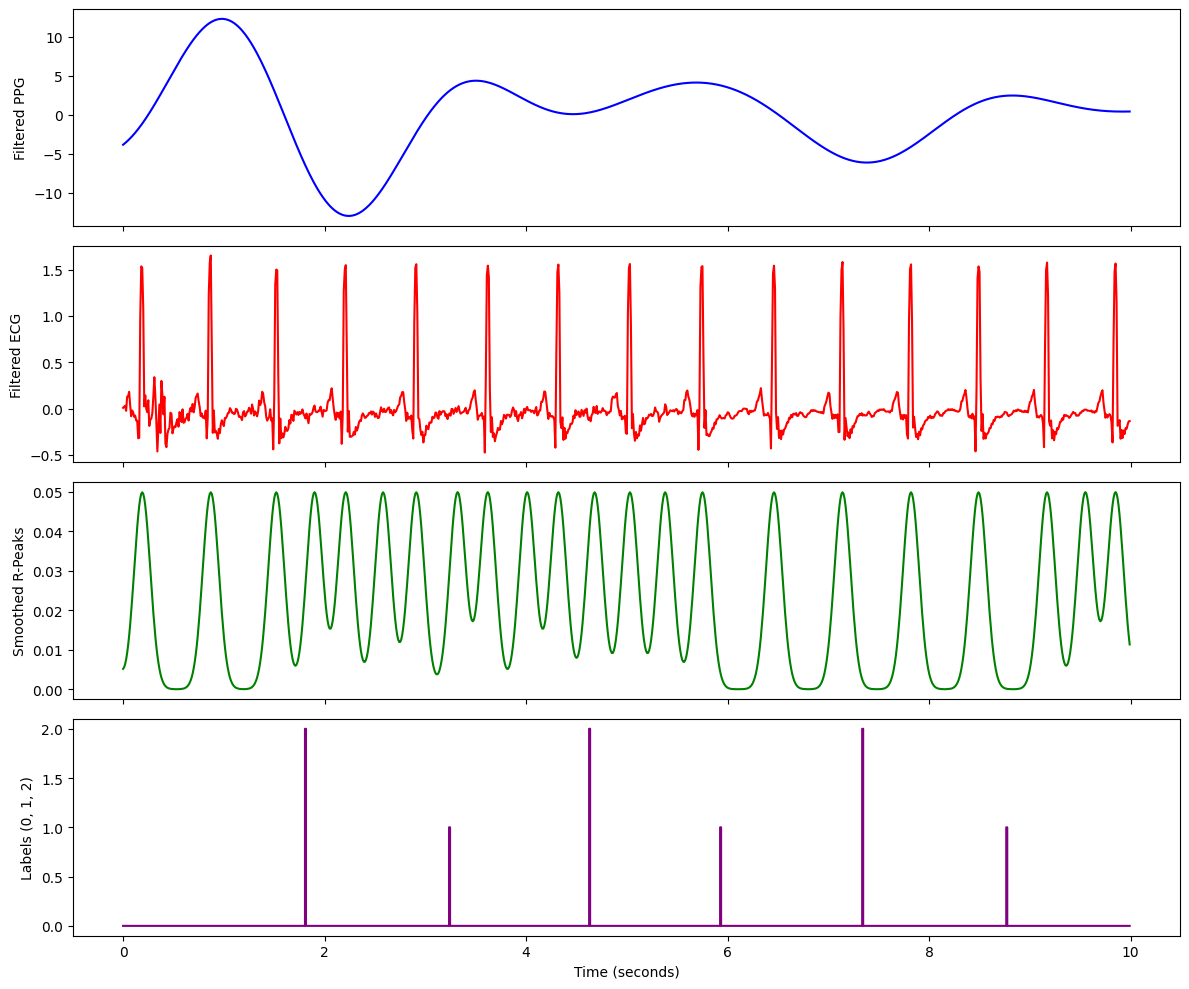

In [16]:
cfg.WESAD_DIR = "/content/drive/MyDrive/Colab_Notebooks/Data/WESAD"

test_loader = WESADLoader(cfg)

sample = test_loader._load_one(f"{cfg.WESAD_DIR}/S16/S16.pkl")

if sample is not None:
    T_plot = 1000
    time = np.arange(T_plot) / cfg.TARGET_FS

    ppg = sample["primary"][:T_plot]
    ecg = sample["auxiliary"][:T_plot]
    rpeaks = sample["aux_marker1"][:T_plot]
    labels = sample["labels"][:T_plot]

    # 4. Create stacked plots
    fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

    axes[0].plot(time, ppg, color='blue')
    axes[0].set_ylabel("Filtered PPG")

    axes[1].plot(time, ecg, color='red')
    axes[1].set_ylabel("Filtered ECG")

    axes[2].plot(time, rpeaks, color='green')
    axes[2].set_ylabel("Smoothed R-Peaks")

    axes[3].plot(time, labels, color='purple', drawstyle='steps-mid')
    axes[3].set_ylabel("Labels (0, 1, 2)")
    axes[3].set_xlabel("Time (seconds)")

    plt.tight_layout()
    plt.show()

else:
    print("File failed quality control or path was incorrect.")


In [ ]:
test_samples = test_loader.load_all()

WESAD: loaded 15 / 15 subjects.
